In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_excel('C:\\Users\\dell\\Downloads\\5-Days-Live-EDA-and-Feature-Engineering-main\\Flight Prediction\\Data_train.xlsx')

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.shape

(10683, 11)

In [5]:
df1=pd.read_excel('C:\\Users\\dell\\Downloads\\5-Days-Live-EDA-and-Feature-Engineering-main\\Flight Prediction\\Test_set.xlsx')
df1.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [6]:
df1.shape

(2671, 10)

In [7]:
final_df = pd.concat([df,df1],ignore_index=True)

In [8]:
final_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0


In [9]:
final_df.shape

(13354, 11)

In [10]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Date_of_Journey  13354 non-null  object 
 2   Source           13354 non-null  object 
 3   Destination      13354 non-null  object 
 4   Route            13353 non-null  object 
 5   Dep_Time         13354 non-null  object 
 6   Arrival_Time     13354 non-null  object 
 7   Duration         13354 non-null  object 
 8   Total_Stops      13353 non-null  object 
 9   Additional_Info  13354 non-null  object 
 10  Price            10683 non-null  float64
dtypes: float64(1), object(10)
memory usage: 1.1+ MB


## Observations
- we need to do lots of `feature engineering` for this inorder to convert `categorical` into `numerical`.

In [11]:
final_df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


## Feature Engineering

In [12]:
final_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0


In [13]:
# final_df['Date_of_Journey'] = final_df['Date_of_Journey'].str.replace('/','-')

In [14]:
# final_df.head()

In [15]:
final_df['Date'] = final_df['Date_of_Journey'].str.split('/').str[0]

In [16]:
final_df['Month'] = final_df['Date_of_Journey'].str.split('/').str[1]

In [17]:
final_df['Year'] = final_df['Date_of_Journey'].str.split('/').str[2]

In [18]:
final_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,24,03,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,1,05,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0,9,06,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0,12,05,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0,01,03,2019


In [19]:
final_df.drop('Date_of_Journey',axis=1,inplace=True)

### converting the date, month, year to the int data type

In [20]:
final_df['Month'] = final_df['Month'].astype('int64')

In [21]:
final_df['Date'] = final_df['Date'].astype('int64')

In [22]:
final_df['Year'] = final_df['Year'].astype('int64')

In [23]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13354 entries, 0 to 13353
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13354 non-null  object 
 1   Source           13354 non-null  object 
 2   Destination      13354 non-null  object 
 3   Route            13353 non-null  object 
 4   Dep_Time         13354 non-null  object 
 5   Arrival_Time     13354 non-null  object 
 6   Duration         13354 non-null  object 
 7   Total_Stops      13353 non-null  object 
 8   Additional_Info  13354 non-null  object 
 9   Price            10683 non-null  float64
 10  Date             13354 non-null  int64  
 11  Month            13354 non-null  int64  
 12  Year             13354 non-null  int64  
dtypes: float64(1), int64(3), object(9)
memory usage: 1.3+ MB


In [24]:
final_df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0,1,3,2019


### considering Arrival Time

In [25]:
final_df['Arrival_Time'] = final_df['Arrival_Time'].str.split(' ').str[0]

In [26]:
final_df.head(1)

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897.0,24,3,2019


In [27]:
final_df['Arrival_Hour'] =  final_df['Arrival_Time'].str.split(':').str[0]

In [28]:
final_df['Arrival_Hour'] = final_df['Arrival_Hour'].astype('int64')

In [29]:
final_df['Arrival_Min'] = final_df['Arrival_Time'].str.split(':').str[1]

In [30]:
final_df['Arrival_Min'] = final_df['Arrival_Min'].astype('int64')

In [31]:
final_df.drop('Arrival_Time',axis=1,inplace=True)

In [32]:
final_df.drop('Arrival_Hours',axis=1,inplace=True)

KeyError: "['Arrival_Hours'] not found in axis"

In [33]:
final_df.head(2)

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897.0,24,3,2019,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,2 stops,No info,7662.0,1,5,2019,13,15


### considering the Dep_time

In [34]:
final_df['Dep_Hour'] = final_df['Dep_Time'].str.split(':').str[0]

In [35]:
final_df['Dep_Hour']=final_df['Dep_Hour'].astype('int64')

In [36]:
final_df['Dep_Min'] = final_df['Dep_Time'].str.split(':').str[1]

In [37]:
final_df['Dep_Min']=final_df['Dep_Min'].astype('int64')

In [38]:
final_df.drop('Dep_Time',axis=1,inplace=True)

In [39]:
final_df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897.0,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662.0,1,5,2019,13,15,5,50


### considering the Duration

In [40]:
final_df['Duration_Hours'] = final_df['Duration'].str.split(' ').str[0].str.split('h').str[0]

In [41]:
final_df['Duration_Min'] = final_df['Duration'].str.split(' ').str[1].str.split('m').str[0]

In [42]:
final_df['Duration_Hours'] = final_df['Duration_Hours'].astype('int64')

ValueError: invalid literal for int() with base 10: '5m'

In [43]:
final_df[final_df['Duration']=='5m']

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_Hours,Duration_Min
6474,Air India,Mumbai,Hyderabad,BOM → GOI → PNQ → HYD,5m,2 stops,No info,17327.0,6,3,2019,16,55,16,50,5m,NaN
13343,Air India,Mumbai,Hyderabad,BOM → GOI → PNQ → HYD,5m,2 stops,No info,NaN,12,3,2019,16,55,16,50,5m,NaN


In [44]:
final_df.drop(6474,axis=0,inplace=True)
final_df.drop(13343,axis=0,inplace=True)

In [45]:
final_df['Duration_Hours'] = final_df['Duration_Hours'].astype('int64')

In [46]:
final_df['Duration_Min'] = final_df['Duration_Min'].fillna(0).astype('int64')

In [47]:
final_df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_Hours,Duration_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897.0,24,3,2019,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662.0,1,5,2019,13,15,5,50,7,25


In [48]:
final_df.Duration_Min.unique()

array([50, 25,  0, 45, 30,  5, 15, 35, 10, 20, 55, 40], dtype=int64)

In [49]:
final_df.drop('Duration',axis=1,inplace=True)

In [50]:
final_df.head(2)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_Hours,Duration_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897.0,24,3,2019,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662.0,1,5,2019,13,15,5,50,7,25


### Considering the Total_stops

In [51]:
final_df.Total_Stops.unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [52]:
final_df[final_df['Total_Stops'].isna()]

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_Hours,Duration_Min
9039,Air India,Delhi,Cochin,NaN,NaN,No info,7480.0,6,5,2019,9,25,9,45,23,40


In [53]:
final_df['Total_Stops'] = final_df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4,np.nan:1}).astype('int64')

In [54]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13352 entries, 0 to 13353
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13352 non-null  object 
 1   Source           13352 non-null  object 
 2   Destination      13352 non-null  object 
 3   Route            13351 non-null  object 
 4   Total_Stops      13352 non-null  int64  
 5   Additional_Info  13352 non-null  object 
 6   Price            10682 non-null  float64
 7   Date             13352 non-null  int64  
 8   Month            13352 non-null  int64  
 9   Year             13352 non-null  int64  
 10  Arrival_Hour     13352 non-null  int64  
 11  Arrival_Min      13352 non-null  int64  
 12  Dep_Hour         13352 non-null  int64  
 13  Dep_Min          13352 non-null  int64  
 14  Duration_Hours   13352 non-null  int64  
 15  Duration_Min     13352 non-null  int64  
dtypes: float64(1), int64(10), object(5)
memory usage: 1.7+ MB


In [55]:
final_df['Total_Stops'].unique()

array([0, 2, 1, 3, 4], dtype=int64)

#### we donot need the route column since we have the total_stops

In [56]:
final_df.drop('Route',inplace=True,axis=1)

In [57]:
final_df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info',
       'Price', 'Date', 'Month', 'Year', 'Arrival_Hour', 'Arrival_Min',
       'Dep_Hour', 'Dep_Min', 'Duration_Hours', 'Duration_Min'],
      dtype='object')

In [58]:
final_df.Airline.unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [59]:
final_df.Source.unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [60]:
final_df.Destination.unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [61]:
final_df.Additional_Info.unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [62]:
# Make everything lowercase and strip spaces
final_df['Additional_Info'] = final_df['Additional_Info'].str.lower().str.strip()

# Check unique values again
final_df['Additional_Info'].unique()

array(['no info', 'in-flight meal not included',
       'no check-in baggage included', '1 short layover',
       '1 long layover', 'change airports', 'business class',
       'red-eye flight', '2 long layover'], dtype=object)

### we can use the labelEncoder for this categorical Columns

In [63]:
from sklearn.preprocessing import LabelEncoder

In [64]:
le = LabelEncoder()

In [65]:
final_df['Additional_Info'] = le.fit_transform(final_df['Additional_Info'])

In [66]:
final_df['Airline']=le.fit_transform(final_df['Airline'])

In [67]:
final_df['Source']=le.fit_transform(final_df['Source'])

In [68]:
final_df['Destination']=le.fit_transform(final_df['Destination'])

In [69]:
final_df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_Hours,Duration_Min
0,3,0,5,0,7,3897.0,24,3,2019,1,10,22,20,2,50
1,1,3,0,2,7,7662.0,1,5,2019,13,15,5,50,7,25
2,4,2,1,2,7,13882.0,9,6,2019,4,25,9,25,19,0
3,3,3,0,1,7,6218.0,12,5,2019,23,30,18,5,5,25
4,3,0,5,1,7,13302.0,1,3,2019,21,35,16,50,4,45


In [70]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13352 entries, 0 to 13353
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          13352 non-null  int32  
 1   Source           13352 non-null  int32  
 2   Destination      13352 non-null  int32  
 3   Total_Stops      13352 non-null  int64  
 4   Additional_Info  13352 non-null  int32  
 5   Price            10682 non-null  float64
 6   Date             13352 non-null  int64  
 7   Month            13352 non-null  int64  
 8   Year             13352 non-null  int64  
 9   Arrival_Hour     13352 non-null  int64  
 10  Arrival_Min      13352 non-null  int64  
 11  Dep_Hour         13352 non-null  int64  
 12  Dep_Min          13352 non-null  int64  
 13  Duration_Hours   13352 non-null  int64  
 14  Duration_Min     13352 non-null  int64  
dtypes: float64(1), int32(4), int64(10)
memory usage: 1.4 MB


- We have completed the feature engineering part.

## Data Analysis

<Axes: xlabel='Price', ylabel='Count'>

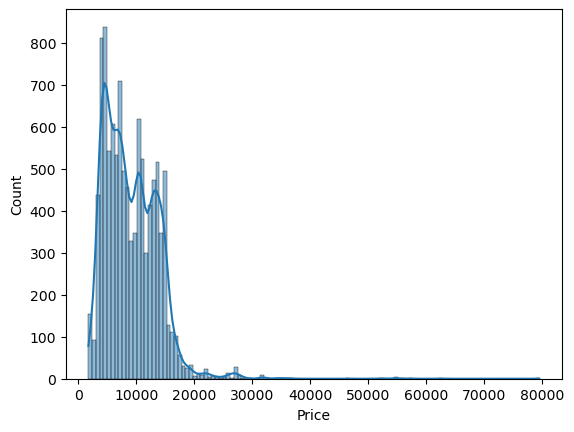

In [71]:
sns.histplot(data=final_df,x='Price',kde=True)

<Axes: xlabel='Price'>

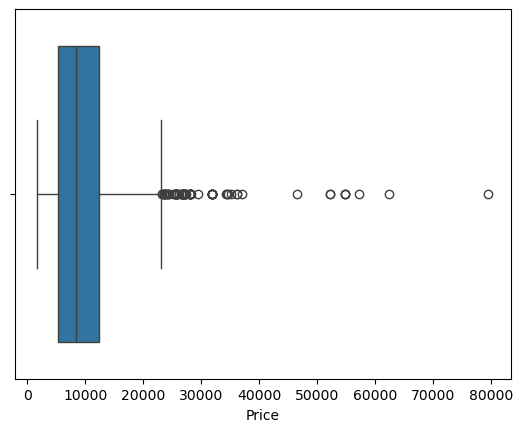

In [72]:
sns.boxplot(data=final_df,x='Price')

### Observations
- Most prices lie below `~20,000`.
- There are many outliers (points outside the whiskers), some going beyond 80,000.
- The distribution is `right-skewed` (many low/mid prices, few extremely high ones).

## Handling Outliers

In [74]:
Q1 = final_df['Price'].quantile(0.25)
Q3 = final_df['Price'].quantile(0.75)

In [75]:
IQR = Q3 - Q1

In [76]:
lower_limit = Q1 - (1.5*IQR)

In [77]:
upper_limit = Q3 + (1.5*IQR)

In [78]:
filtered_df = final_df[(final_df['Price']>=lower_limit) & (final_df['Price']<=upper_limit)]

<Axes: xlabel='Price'>

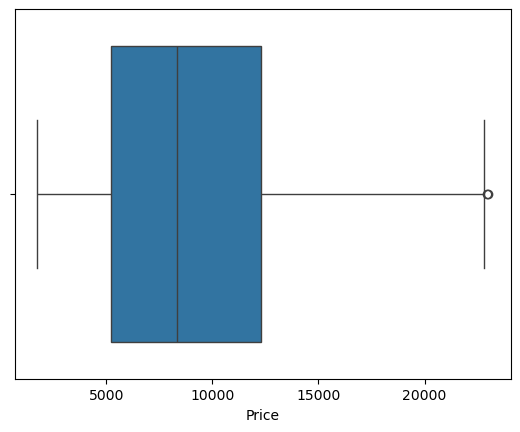

In [79]:
sns.boxplot(data=filtered_df,x='Price')

In [80]:
filtered_df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_Hours,Duration_Min
0,3,0,5,0,7,3897.0,24,3,2019,1,10,22,20,2,50
1,1,3,0,2,7,7662.0,1,5,2019,13,15,5,50,7,25
2,4,2,1,2,7,13882.0,9,6,2019,4,25,9,25,19,0
3,3,3,0,1,7,6218.0,12,5,2019,23,30,18,5,5,25
4,3,0,5,1,7,13302.0,1,3,2019,21,35,16,50,4,45


## now we can check for the correlation

In [81]:
corr = filtered_df.corr()
corr

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_Hours,Duration_Min
Airline,1.000000,-0.014179,0.020795,-0.200087,-0.082009,-0.045019,0.025776,0.023905,NaN,-0.005691,-0.071088,-0.035632,-0.059506,-0.157496,-0.028179
Source,-0.014179,1.000000,-0.584150,0.197421,-0.030910,0.075007,-0.010157,0.171769,NaN,0.024966,0.019297,0.059704,-0.051261,0.170529,-0.146494
Destination,0.020795,-0.584150,1.000000,-0.308768,0.033998,-0.171394,-0.018993,-0.350913,NaN,-0.040281,0.018735,-0.074332,0.120389,-0.269102,0.063179
Total_Stops,-0.200087,0.197421,-0.308768,1.000000,-0.067911,0.667566,-0.004438,0.061414,NaN,0.040220,-0.108424,-0.061550,-0.005108,0.742013,-0.137052
Additional_Info,-0.082009,-0.030910,0.033998,-0.067911,1.000000,-0.030710,-0.024938,-0.058250,NaN,0.031449,0.040221,-0.048859,-0.013922,-0.158106,0.048560
Price,-0.045019,0.075007,-0.171394,0.667566,-0.030710,1.000000,-0.118330,-0.050586,NaN,0.037617,-0.097638,0.006891,-0.053284,0.575214,-0.138878
Date,0.025776,-0.010157,-0.018993,-0.004438,-0.024938,-0.118330,1.000000,-0.055920,NaN,-0.004010,-0.017759,0.000967,-0.002781,-0.018781,-0.009156
Month,0.023905,0.171769,-0.350913,0.061414,-0.058250,-0.050586,-0.055920,1.000000,NaN,-0.005677,-0.101881,0.039841,-0.053668,0.019605,-0.042160
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arrival_Hour,-0.005691,0.024966,-0.040281,0.040220,0.031449,0.037617,-0.004010,-0.005677,NaN,1.000000,-0.153375,0.007845,0.044508,0.055670,-0.117959


<Axes: >

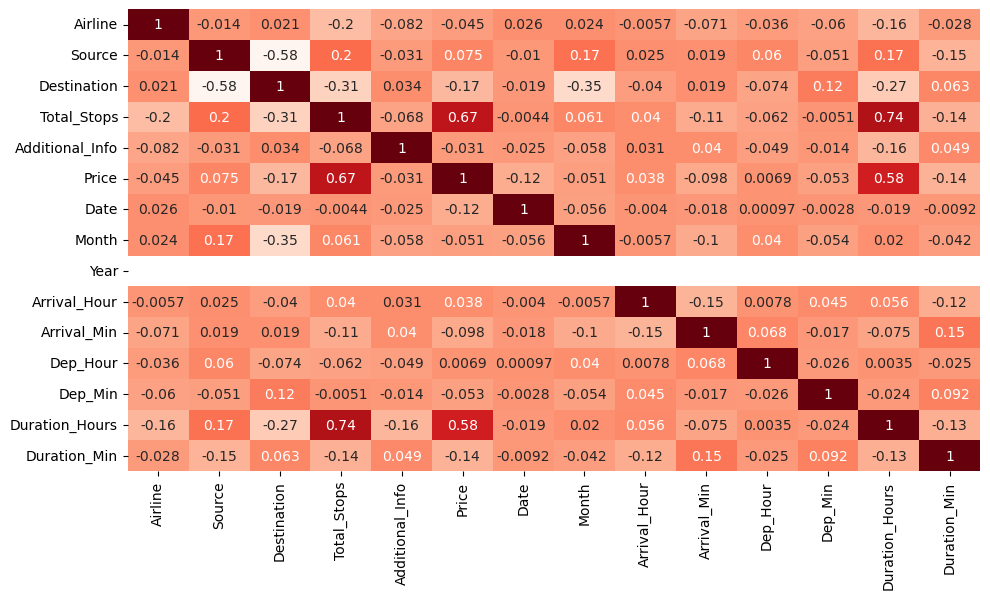

In [82]:
plt.figure(figsize=(11,6))
sns.heatmap(data=corr.drop('Year',axis=1),cmap='Reds',cbar=False,annot=True)

### Observations:

- The highest correlation is between:
- ➡ Total_Stops and Duration_Hours (0.74)
- Followed by:
- ➡ Total_Stops and Price (0.67)
- ➡ Duration_Hours and Price (0.58)

<Axes: xlabel='Duration_Hours', ylabel='Price'>

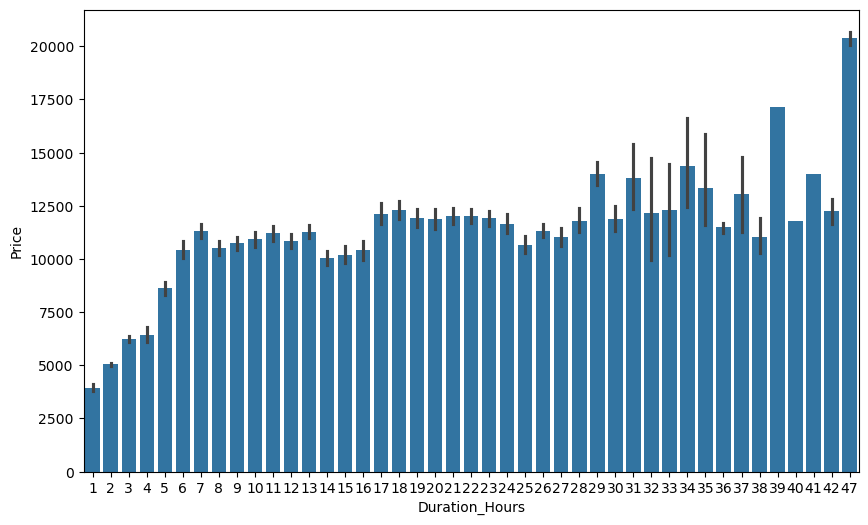

In [83]:
plt.figure(figsize=(10,6))
sns.barplot(data=filtered_df,x='Duration_Hours',y='Price')

<Axes: xlabel='Duration_Min', ylabel='Price'>

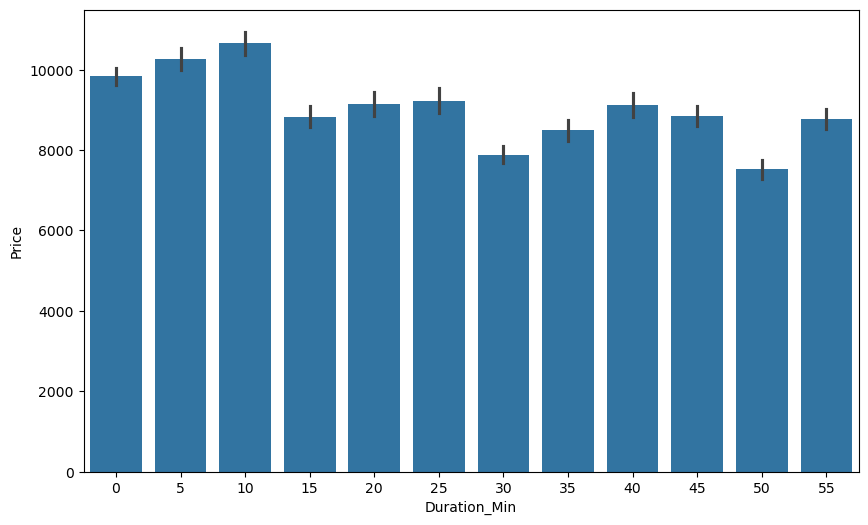

In [84]:
plt.figure(figsize=(10,6))
sns.barplot(data=filtered_df,x='Duration_Min',y='Price')

<Axes: xlabel='Total_Stops', ylabel='Price'>

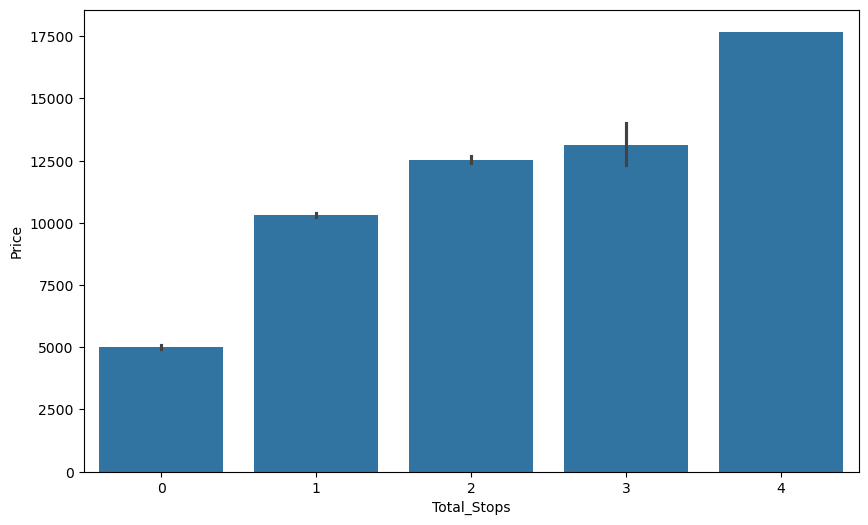

In [85]:
plt.figure(figsize=(10,6))
sns.barplot(data=filtered_df,x='Total_Stops',y='Price')

<Axes: xlabel='Airline', ylabel='Price'>

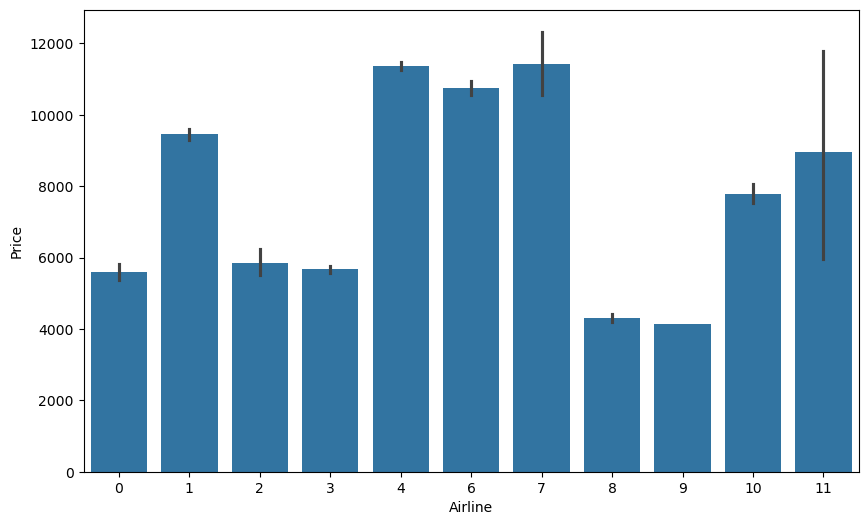

In [86]:
plt.figure(figsize=(10,6))
sns.barplot(data=filtered_df,x='Airline',y='Price')

<Axes: xlabel='Source', ylabel='Price'>

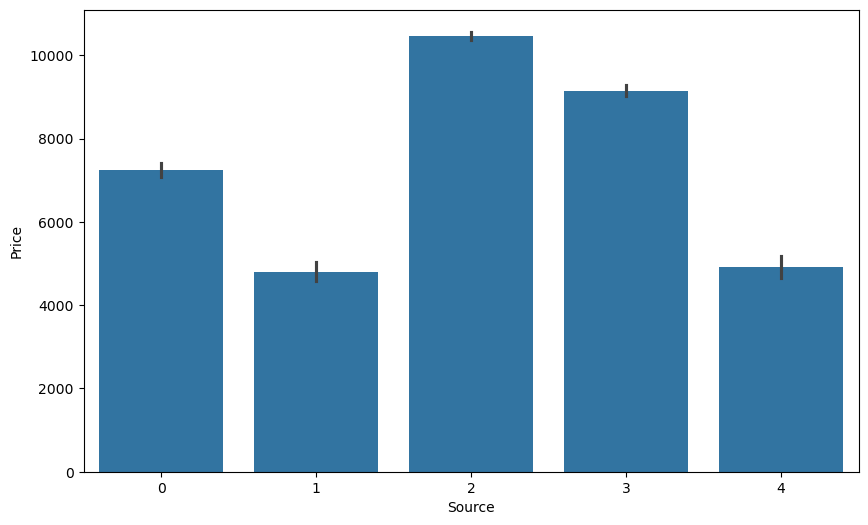

In [87]:
plt.figure(figsize=(10,6))
sns.barplot(data=filtered_df,x='Source',y='Price')

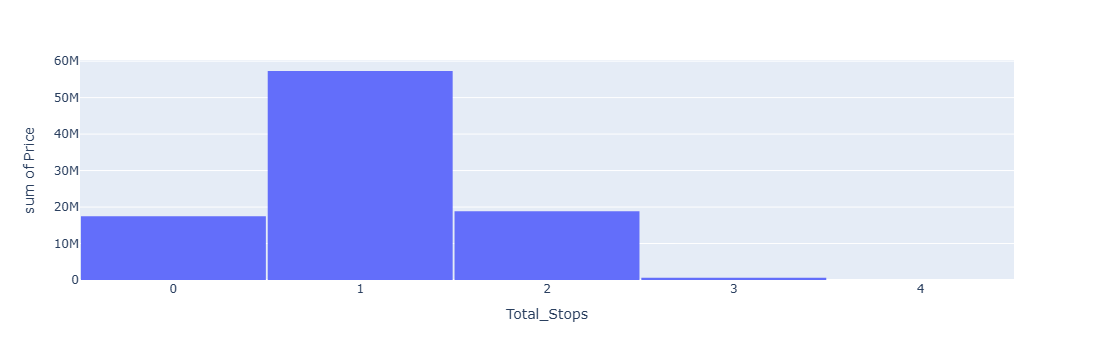

In [88]:
fig=px.histogram(filtered_df,x='Total_Stops',y='Price')
fig.update_layout(bargap=0.01)

In [89]:
filtered_df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info',
       'Price', 'Date', 'Month', 'Year', 'Arrival_Hour', 'Arrival_Min',
       'Dep_Hour', 'Dep_Min', 'Duration_Hours', 'Duration_Min'],
      dtype='object')

## considering the inputs and targets

In [90]:
inputs = filtered_df.drop('Price',axis=1)
targets = filtered_df['Price']

In [91]:
inputs.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_Hours,Duration_Min
0,3,0,5,0,7,24,3,2019,1,10,22,20,2,50
1,1,3,0,2,7,1,5,2019,13,15,5,50,7,25
2,4,2,1,2,7,9,6,2019,4,25,9,25,19,0
3,3,3,0,1,7,12,5,2019,23,30,18,5,5,25
4,3,0,5,1,7,1,3,2019,21,35,16,50,4,45


#### Here we have to encode the `date`,`month` and `year` saperately
- we can use the `cyclical encoding`
- ➤ What is cyclic encoding and why do we use it?

- Some features like `Month (1 to 12) or Date (1 to 31) are cyclical — after December (12), January (1) comes again`; similarly, `after day 31, day 1 starts again`.

- If we encode them as plain numbers (e.g. 1, 2, …, 12), a model might think that December (12) is far from January (1), even though they are actually next to each other.

In [92]:
inputs['Month_sin'] = np.sin(2* np.pi * inputs['Month']/12)
inputs['Month_cos'] = np.cos(2* np.pi * inputs['Month']/12)

In [93]:
final_df['Date_sin'] = np.sin(2 * np.pi * inputs['Date']/31)
final_df['Date_cos'] = np.cos(2 * np.pi * inputs['Date']/31)

In [94]:
inputs.drop(['Month','Date'],axis=1,inplace=True)

In [95]:
inputs.drop('Year',axis=1,inplace=True)

In [96]:
inputs.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_Hours,Duration_Min,Month_sin,Month_cos
0,3,0,5,0,7,1,10,22,20,2,50,1.000000e+00,6.123234e-17
1,1,3,0,2,7,13,15,5,50,7,25,5.000000e-01,-8.660254e-01
2,4,2,1,2,7,4,25,9,25,19,0,1.224647e-16,-1.000000e+00
3,3,3,0,1,7,23,30,18,5,5,25,5.000000e-01,-8.660254e-01
4,3,0,5,1,7,21,35,16,50,4,45,1.000000e+00,6.123234e-17


In [97]:
from sklearn.preprocessing import StandardScaler

In [98]:
scaler = StandardScaler()
cols_to_scale = ['Arrival_Hour', 'Arrival_Min', 'Dep_Hour', 'Dep_Min', 'Duration_Hours', 'Duration_Min']
inputs[cols_to_scale] = scaler.fit_transform(inputs[cols_to_scale])

In [99]:
inputs.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_Hours,Duration_Min,Month_sin,Month_cos
0,3,0,5,0,7,-1.802754,-0.888713,1.655467,-0.231004,-0.967552,1.277225,1.000000e+00,6.123234e-17
1,1,3,0,2,7,-0.052204,-0.586219,-1.303888,1.370918,-0.379555,-0.196603,5.000000e-01,-8.660254e-01
2,4,2,1,2,7,-1.365117,0.018770,-0.607569,0.035983,1.031638,-1.670431,1.224647e-16,-1.000000e+00
3,3,3,0,1,7,1.406588,0.321265,0.959148,-1.031965,-0.614754,-0.196603,5.000000e-01,-8.660254e-01
4,3,0,5,1,7,1.114830,0.623759,0.610989,1.370918,-0.732353,0.982459,1.000000e+00,6.123234e-17


## Considering the models

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
X_train,X_test,y_train,y_test = train_test_split(inputs,targets,test_size=0.2,random_state=42)

In [102]:
from sklearn.linear_model import LinearRegression

In [103]:
model  = LinearRegression().fit(X_train,y_train)

In [104]:
preds= model.predict(X_test)

In [105]:
preds

array([13380.20386946, 14253.83692919,  9032.95415406, ...,
       12749.696016  ,  8979.69899301,  6222.0230297 ])

## checking the loss value and r2_score

In [106]:
from sklearn.metrics import mean_squared_error,r2_score

In [107]:
loss = np.sqrt(mean_squared_error(y_test,preds))
r2 = r2_score(y_test,preds)

In [108]:
loss,r2

(2952.300659389479, 0.47602691308460776)

## try to use another models

In [109]:
from sklearn.tree import DecisionTreeRegressor

In [110]:
model = DecisionTreeRegressor(max_features=8,random_state=42,max_depth=11).fit(X_train,y_train)

In [111]:
preds = model.predict(X_test)
preds

array([ 7945.57692308, 14548.4       ,  8282.14893617, ...,
       11432.        , 14679.18181818,  4151.73684211])

In [112]:
loss = np.sqrt(mean_squared_error(y_test,preds))
r2 = r2_score(y_test,preds)
loss,r2

(1894.7433399112763, 0.7841815386392754)

## using the RandomForestRegressor

In [113]:
from sklearn.ensemble import RandomForestRegressor

In [114]:
model = RandomForestRegressor(n_estimators=400,max_depth=12,random_state=42,n_jobs=-1).fit(X_train,y_train)

In [115]:
preds=model.predict(X_test)

In [116]:
loss = np.sqrt(mean_squared_error(y_test,preds))
r2 = r2_score(y_test,preds)
loss,r2

(1779.3453390132088, 0.8096695371660492)

## using the XGBoost

In [117]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=800,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [118]:
preds=xgb_model.predict(X_test)

In [119]:
loss = np.sqrt(mean_squared_error(y_test,preds))
r2 = r2_score(y_test,preds)
loss,r2

(1930.7980346958998, 0.7758898584979186)

## RandomForestRegressor Performed best among all

In [ ]:
## i will try to implement the 